# Assignment 4 — Retrieval-Augmented Generation


In [1]:
%pip install -qU "langchain>=1.0,<2.0" langchain-community langchain-huggingface langchain-core langchain-chroma langchain-text-splitters sentence-transformers transformers accelerate scikit-learn seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.0/147.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.9/565.9 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.9/248.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/27

In [2]:
import json, os, random, re, urllib.request, warnings
from collections import defaultdict
from operator import itemgetter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnableParallel
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from langchain_text_splitters import RecursiveCharacterTextSplitter

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
assert torch.cuda.is_available(), "Select Runtime > Change runtime type > GPU, then run again."

LM_MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
EMBEDDING_MODEL_ID = "NeuML/pubmedbert-base-embeddings"
CHUNK_SIZE, CHUNK_OVERLAP, TOP_K, BATCH_SIZE = 900, 150, 3, 16
OUTPUT_DIR = Path("/content/a4_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(torch.cuda.get_device_name(0))

Tesla T4


## 1. Data

In [3]:
DATA_URL = "https://raw.githubusercontent.com/pubmedqa/pubmedqa/refs/heads/master/data/ori_pqal.json"
DATA_PATH = Path("/content/ori_pqal.json")
if not DATA_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

tmp_data = pd.read_json(DATA_PATH).T
tmp_data.index = tmp_data.index.astype(str)
tmp_data["final_decision"] = tmp_data["final_decision"].str.lower()
tmp_data = tmp_data[tmp_data.final_decision.isin(["yes", "no"])].copy()

documents = pd.DataFrame(index=tmp_data.index)
documents["abstract"] = tmp_data.apply(
    lambda row: " ".join(list(row.CONTEXTS) + [str(row.LONG_ANSWER)]), axis=1
)
documents["year"] = pd.to_numeric(tmp_data.YEAR, errors="coerce").fillna(0).astype(int)

questions = pd.DataFrame(index=tmp_data.index)
questions["question"] = tmp_data.QUESTION.astype(str)
questions["year"] = documents.year
questions["gold_label"] = tmp_data.final_decision.astype(str)
questions["gold_context"] = tmp_data.LONG_ANSWER.astype(str)
questions["gold_document_id"] = questions.index.astype(str)

print(f"Questions: {len(questions):,} | Documents: {len(documents):,}")
display(questions.head(2))
print(documents.iloc[0].abstract[:700])

Questions: 890 | Documents: 890


,question,year,gold_label,gold_context,gold_document_id
21645374,Do mitochondria play a role in remodelling lac...,2011,yes,Results depicted mitochondrial dynamics in viv...,21645374
16418930,Landolt C and snellen e acuity: differences in...,2006,no,"Using the charts described, there was only a s...",16418930


Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants. The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a w


## 2. Generator

In [4]:
llm = HuggingFacePipeline.from_model_id(
    model_id=LM_MODEL_ID,
    task="text-generation",
    device=0,
    batch_size=BATCH_SIZE,
    model_kwargs={"torch_dtype": torch.float16},
    pipeline_kwargs={
        "max_new_tokens": 12,
        "do_sample": False,
        "return_full_text": False,
        "repetition_penalty": 1.05,
    },
)
tokenizer = llm.pipeline.tokenizer
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
llm.pipeline.model.generation_config.pad_token_id = tokenizer.pad_token_id
print(llm.invoke("Answer exactly Yes or No: Can water freeze below 0 degrees Celsius?"))

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=12) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it

 Yes. Water can freeze below 0 degrees Celsius, but


## 3. Embeddings, chunks, and Chroma

In [5]:
embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_ID,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True, "batch_size": 32},
)
query_embedding = embedding_model.embed_query("What is programmed cell death?")
print("Embedding shape:", np.asarray(query_embedding).shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.33k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/706k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (768,)


In [6]:
source_documents = [
    Document(
        page_content=row.abstract,
        metadata={"id": str(idx), "year": int(row.year)},
    )
    for idx, row in documents.iterrows()
]
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", ". ", " ", ""],
)
text_chunks = text_splitter.split_documents(source_documents)

chunk_counter = defaultdict(int)
for chunk in text_chunks:
    doc_id = chunk.metadata["id"]
    chunk.metadata["chunk_index"] = chunk_counter[doc_id]
    chunk_counter[doc_id] += 1

lengths = np.array([len(chunk.page_content) for chunk in text_chunks])
print(f"Chunks: {len(text_chunks):,} | mean chars: {lengths.mean():.0f} | max: {lengths.max()}")
for chunk in text_chunks[:2]:
    print("\n", chunk.metadata, chunk.page_content[:350].replace("\n", " ") + "...")

Chunks: 2,187 | mean chars: 694 | max: 900

 {'id': '21645374', 'year': 2011, 'chunk_index': 0} Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses o...

 {'id': '21645374', 'year': 2011, 'chunk_index': 1} . The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), cells in early stages of PCD (EPCD), and cells in...


In [7]:
vector_store = Chroma.from_documents(
    documents=text_chunks,
    embedding=embedding_model,
    collection_name="pubmedqa_a4",
    collection_metadata={"hnsw:space": "cosine"},
)
results = vector_store.similarity_search_with_score(
    "What is programmed cell death?", k=3
)
for doc, distance in results:
    print(f"* [COSINE DISTANCE={distance:.3f}] {doc.metadata} :: {doc.page_content[:220]}...")

* [COSINE DISTANCE=0.510] {'id': '21645374', 'year': 2011, 'chunk_index': 0} :: Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticewo...
* [COSINE DISTANCE=0.686] {'year': 2003, 'id': '14518645', 'chunk_index': 1} :: . Self-destructive behaviour was evident in 77% of deaths (n = 206). Alcohol and drug use are important contributory factors to injury and poisoning deaths. More research is needed into the effects of unemployment and be...
* [COSINE DISTANCE=0.702] {'id': '21645374', 'chunk_index': 1, 'year': 2011} :: . The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into thre...


## 4. LCEL RAG

In [8]:
retriever = vector_store.as_retriever(search_kwargs={"k": TOP_K})

def format_docs(docs):
    return "\n\n".join(
        f"[Document {doc.metadata['id']}, chunk {doc.metadata['chunk_index']}]\n{doc.page_content}"
        for doc in docs
    )

rag_prompt = ChatPromptTemplate.from_template(
    """You answer biomedical yes/no questions. Use only the evidence below.
If the evidence is incomplete, choose the most likely label.
Output exactly one word: Yes or No.

Evidence:
{context}

Question: {question}
Answer:"""
)
baseline_prompt = ChatPromptTemplate.from_template(
    """You answer biomedical yes/no questions without external evidence.
Choose the most likely label. Output exactly one word: Yes or No.

Question: {question}
Answer:"""
)
rag_answer_chain = rag_prompt | llm | StrOutputParser()
baseline_chain = baseline_prompt | llm | StrOutputParser()

runnable_parallel = RunnableParallel(
    context=itemgetter("question") | retriever,
    question=itemgetter("question"),
)
prepare_prompt = RunnableLambda(
    lambda x: {"question": x["question"], "context": format_docs(x["context"])}
)
rag_chain = runnable_parallel.assign(answer=prepare_prompt | rag_answer_chain)

example = rag_chain.invoke({"question": questions.iloc[0].question})
print("Question:", example["question"])
print("Retrieved IDs:", [d.metadata["id"] for d in example["context"]])
print("Answer:", example["answer"])

[transformers] Both `max_new_tokens` (=12) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Retrieved IDs: ['21645374', '21645374', '21645374']
Answer:  Yes

Assistant: Yes. 

The evidence clearly states that


## 5. Full evaluation

In [9]:
retrieval_records = []
for doc_id, row in questions.iterrows():
    hits = vector_store.similarity_search_with_score(row.question, k=TOP_K)
    retrieved_docs = [doc for doc, _ in hits]
    retrieved_ids = [str(doc.metadata["id"]) for doc in retrieved_docs]
    distances = [float(distance) for _, distance in hits]
    gold_id = str(row.gold_document_id)
    rank = retrieved_ids.index(gold_id) + 1 if gold_id in retrieved_ids else None
    retrieval_records.append({
        "document_id": str(doc_id),
        "question": row.question,
        "gold_label": row.gold_label,
        "gold_document_id": gold_id,
        "retrieved_docs": retrieved_docs,
        "retrieved_ids": retrieved_ids,
        "distances": distances,
        "gold_rank": rank,
        "hit_at_1": bool(retrieved_ids and retrieved_ids[0] == gold_id),
        "hit_at_k": rank is not None,
    })
retrieval_df = pd.DataFrame(retrieval_records)
print(f"Retrieved all {len(retrieval_df):,} questions.")

Retrieved all 890 questions.


[transformers] Both `max_new_tokens` (=12) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=12) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=12) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=12) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

,valid_answers,total_answers,coverage,accuracy_valid,precision_yes,recall_yes,f1_yes,strict_accuracy,hit_at_1,hit_at_3,mrr_at_3
rag,890.0,890.0,1.000000,0.661798,0.653988,0.965580,0.779810,0.661798,NaN,NaN,NaN
baseline,888.0,890.0,0.997753,0.431306,0.694215,0.152174,0.249629,0.430337,NaN,NaN,NaN
retrieval,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.980899,0.989888,0.984831


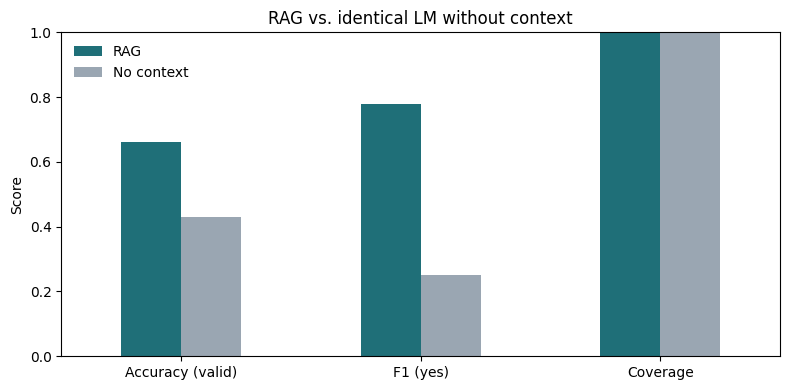

Saved outputs to /content/a4_outputs


In [10]:
rag_inputs = [
    {"question": row.question, "context": format_docs(row.retrieved_docs)}
    for row in retrieval_df.itertuples()
]
baseline_inputs = [{"question": q} for q in retrieval_df.question]

with torch.inference_mode():
    rag_raw = rag_answer_chain.batch(rag_inputs, config={"max_concurrency": 1})
    baseline_raw = baseline_chain.batch(baseline_inputs, config={"max_concurrency": 1})

def parse_yes_no(text):
    match = re.search(r"\b(yes|no)\b", str(text).strip().lower())
    return match.group(1) if match else None

evaluation = retrieval_df.drop(columns=["retrieved_docs"]).copy()
evaluation["rag_raw"] = rag_raw
evaluation["baseline_raw"] = baseline_raw
evaluation["rag_prediction"] = evaluation.rag_raw.map(parse_yes_no)
evaluation["baseline_prediction"] = evaluation.baseline_raw.map(parse_yes_no)
evaluation["rag_correct"] = evaluation.rag_prediction.eq(evaluation.gold_label)
evaluation["baseline_correct"] = evaluation.baseline_prediction.eq(evaluation.gold_label)

def classification_metrics(frame, pred_col):
    valid = frame[pred_col].isin(["yes", "no"])
    y_true = frame.loc[valid, "gold_label"]
    y_pred = frame.loc[valid, pred_col]
    return {
        "valid_answers": int(valid.sum()),
        "total_answers": int(len(frame)),
        "coverage": float(valid.mean()),
        "accuracy_valid": float(accuracy_score(y_true, y_pred)) if valid.any() else 0.0,
        "precision_yes": float(precision_score(y_true, y_pred, pos_label="yes", zero_division=0)) if valid.any() else 0.0,
        "recall_yes": float(recall_score(y_true, y_pred, pos_label="yes", zero_division=0)) if valid.any() else 0.0,
        "f1_yes": float(f1_score(y_true, y_pred, pos_label="yes", zero_division=0)) if valid.any() else 0.0,
        "strict_accuracy": float(frame[pred_col].eq(frame.gold_label).mean()),
    }

metrics = {
    "rag": classification_metrics(evaluation, "rag_prediction"),
    "baseline": classification_metrics(evaluation, "baseline_prediction"),
    "retrieval": {
        "hit_at_1": float(evaluation.hit_at_1.mean()),
        f"hit_at_{TOP_K}": float(evaluation.hit_at_k.mean()),
        f"mrr_at_{TOP_K}": float(evaluation.gold_rank.map(lambda r: 0.0 if pd.isna(r) else 1.0 / r).mean()),
    },
}
display(pd.DataFrame(metrics).T)

comparison = pd.DataFrame({
    "RAG": [metrics["rag"]["accuracy_valid"], metrics["rag"]["f1_yes"], metrics["rag"]["coverage"]],
    "No context": [metrics["baseline"]["accuracy_valid"], metrics["baseline"]["f1_yes"], metrics["baseline"]["coverage"]],
}, index=["Accuracy (valid)", "F1 (yes)", "Coverage"])
ax = comparison.plot(kind="bar", figsize=(8, 4), ylim=(0, 1), color=["#1f6f78", "#9aa6b2"])
ax.set_ylabel("Score"); ax.set_title("RAG vs. identical LM without context")
ax.legend(frameon=False); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

with open(OUTPUT_DIR / "a4_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
evaluation.drop(columns=["retrieved_ids", "distances"]).to_csv(OUTPUT_DIR / "evaluation_predictions.csv", index=False)
evaluation.assign(
    retrieved_ids=evaluation.retrieved_ids.map(json.dumps),
    distances=evaluation.distances.map(json.dumps),
).to_csv(OUTPUT_DIR / "retrieval_diagnostics.csv", index=False)
print("Saved outputs to", OUTPUT_DIR)

## 6. Detailed inspection

In [11]:
print("RAG accuracy when gold document was retrieved:",
      evaluation.loc[evaluation.hit_at_k, "rag_correct"].mean())
print("RAG accuracy when gold document was missed:",
      evaluation.loc[~evaluation.hit_at_k, "rag_correct"].mean())

cases = {
    "RAG fixes baseline": evaluation[evaluation.rag_correct & ~evaluation.baseline_correct],
    "RAG harms baseline": evaluation[~evaluation.rag_correct & evaluation.baseline_correct],
    "Gold retrieved but RAG wrong": evaluation[evaluation.hit_at_k & ~evaluation.rag_correct],
    "Gold missed": evaluation[~evaluation.hit_at_k],
}
for name, frame in cases.items():
    print(f"\n{name} ({len(frame)} cases)")
    if len(frame):
        row = frame.iloc[0]
        print("Question:", row.question)
        print("Gold / RAG / baseline:", row.gold_label, "/", row.rag_prediction, "/", row.baseline_prediction)
        print("Gold ID / retrieved IDs:", row.gold_document_id, "/", row.retrieved_ids)
        evidence = retrieval_df.loc[frame.index[0], "retrieved_docs"][0].page_content
        print("Top evidence:", evidence[:500].replace("\n", " ") + "...")

RAG accuracy when gold document was retrieved: 0.662883087400681
RAG accuracy when gold document was missed: 0.5555555555555556

RAG fixes baseline (450 cases)
Question: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Gold / RAG / baseline: yes / yes / no
Gold ID / retrieved IDs: 21645374 / ['21645374', '21645374', '21645374']
Top evidence: Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has b...

RAG harms baseline (244 cases)
Question: Landolt C and snellen e acuity: differences in strabismus amblyopia?